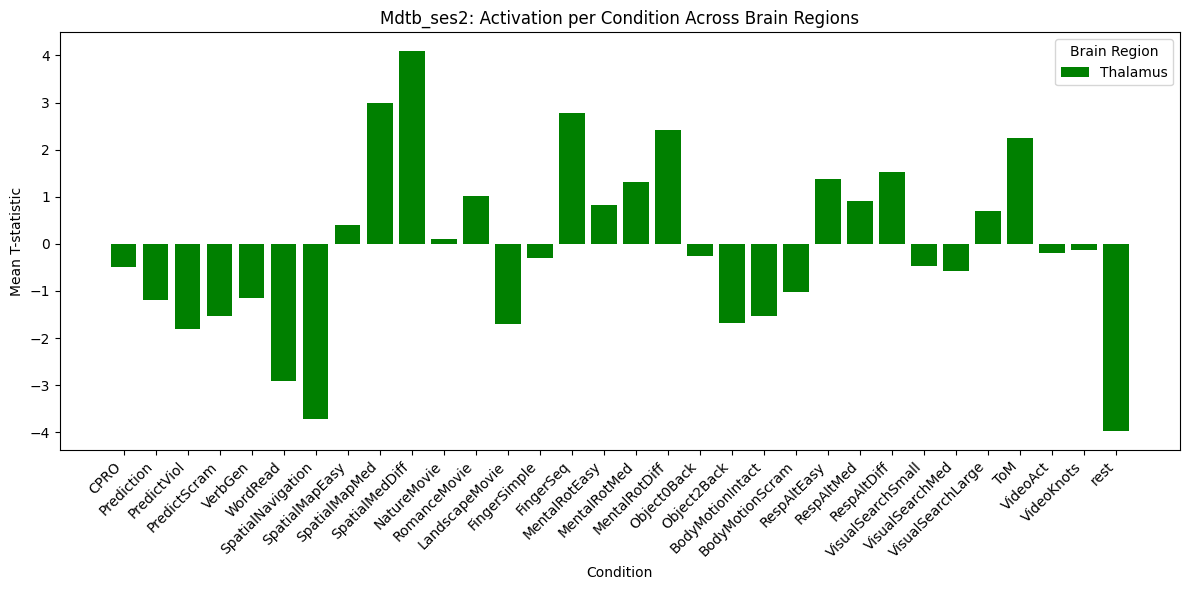

In [67]:
import nibabel as nb
import numpy as np
import matplotlib.pyplot as plt

wk_dir = f'/Volumes/diedrichsen_data$/data/Cerebellum/Pontine7T/atlases'
dataset = "mdtb_ses2"

region_files = {
    #"Olive": f"{wk_dir}/olive/contrasts/{dataset}_olive_condavg_Tstat.dscalar.nii",
    #"Dentate": f"{wk_dir}/dentate/contrasts/{dataset}_condavg_Tstat.dscalar.nii",
   # "Red Nucleus": f"{wk_dir}/rednucleus/contrasts/{dataset}_rednucleus_condavg_Tstat.dscalar.nii",
    #"Pontine": f"{wk_dir}/pontine/contrasts/{dataset}_pontine_condavg_Tstat.dscalar.nii",
    "Thalamus": f"{wk_dir}/thalamus/contrasts/{dataset}_thalamus_condavg_Tstat.dscalar.nii",
    #"Cerebellar cortex": f"{wk_dir}/dentate/contrasts/cereb_gray_references/{dataset}_cereb_condavg_Tstat.dscalar.nii"
}

region_activations = {}
condition_names = None

for region, path in region_files.items():
    img = nb.load(path)
    data = img.get_fdata()
    
    if condition_names is None:
        axis = img.header.get_axis(0)
        condition_names = axis.name
    
    mean_activation = np.mean(data, axis=1)
    region_activations[region] = mean_activation


x = np.arange(len(condition_names))  # base positions
n_regions = len(region_activations)
width = 0.8 / n_regions  # total group width = 0.8

plt.figure(figsize=(12,6))

colors = ["green"]  # one per region

for i, (region, values) in enumerate(region_activations.items()):
    offset = (i - (n_regions - 1)/2) * width  # center bars
    plt.bar(x + offset, values, width, label=region, color=colors[i])

plt.xticks(x, condition_names, rotation=45, ha='right')

plt.ylabel("Mean T-statistic")
plt.xlabel("Condition")
plt.title(f"{dataset.capitalize()}: Activation per Condition Across Brain Regions")

plt.legend(title="Brain Region")

plt.tight_layout()
plt.show()



In [46]:
import Functional_Fusion.dataset as ds
from scripts import decomposing_variances


base_dir = '/Volumes/diedrichsen_data$/data/FunctionalFusion_new' 


data, info, ds_obj = ds.get_dataset(base_dir,'Language',atlas='MNISymOlive1',
                                        sess='ses-localizerfm', 
                                        subj=None, type='CondRun')

cond_v = info['task_name']
part_v = info['run']

data = ds.remove_baseline(data,part_v)

flat_data = decomposing_variances.flat2ndarray(data, cond_v, part_v)

flat_data = np.nan_to_num(flat_data)

print(flat_data.shape)

(17, 8, 18, 1448)


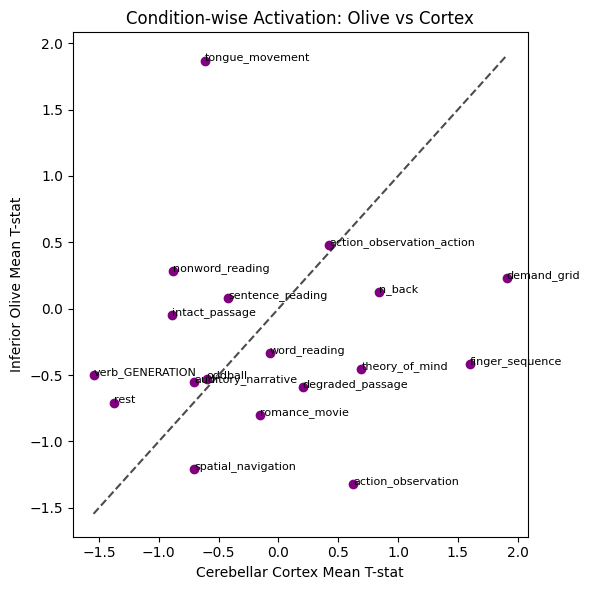

In [27]:
import nibabel as nb
import numpy as np
import matplotlib.pyplot as plt

dataset = "language"

# File paths
olive_path = f"{wk_dir}/olive/contrasts/{dataset}_olive_condavg_Tstat.dscalar.nii"
cortex_path = f"{wk_dir}/dentate/contrasts/cereb_gray_references/{dataset}_cereb_condavg_Tstat.dscalar.nii"
# Load data
olive_img = nb.load(olive_path)
cortex_img = nb.load(cortex_path)

olive_data = olive_img.get_fdata()
cortex_data = cortex_img.get_fdata()

# Condition names
axis = olive_img.header.get_axis(0)
condition_names = axis.name

olive_mean = np.mean(olive_data, axis=1)
cortex_mean = np.mean(cortex_data, axis=1)

plt.figure(figsize=(6,6))

plt.scatter(cortex_mean, olive_mean, color='purple')

# Add labels for each condition
for i, name in enumerate(condition_names):
    plt.text(cortex_mean[i], olive_mean[i], name, fontsize=8)

# Diagonal reference line
lims = [
    min(cortex_mean.min(), olive_mean.min()),
    max(cortex_mean.max(), olive_mean.max())
]

plt.plot(lims, lims, 'k--', alpha=0.7)

plt.xlabel("Cerebellar Cortex Mean T-stat")
plt.ylabel("Inferior Olive Mean T-stat")
plt.title("Condition-wise Activation: Olive vs Cortex")

plt.tight_layout()
plt.show()

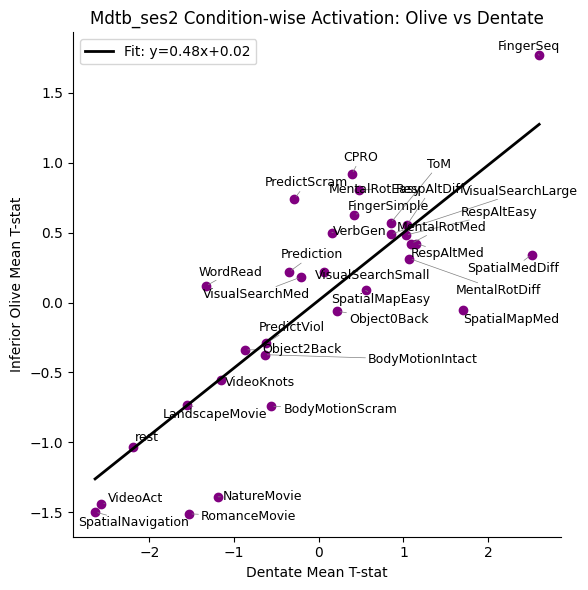

In [43]:
import nibabel as nb
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

dataset = "mdtb_ses2"

# File paths
olive_path = f"{wk_dir}/olive/contrasts/{dataset}_olive_condavg_Tstat.dscalar.nii"
cortex_path = f"{wk_dir}/dentate/contrasts/{dataset}_dentate_condavg_Tstat.dscalar.nii"
# Load data
olive_img = nb.load(olive_path)
cortex_img = nb.load(cortex_path)

olive_data = olive_img.get_fdata()
cortex_data = cortex_img.get_fdata()

# Condition names
axis = olive_img.header.get_axis(0)
condition_names = axis.name

olive_mean = np.mean(olive_data, axis=1)
cortex_mean = np.mean(cortex_data, axis=1)

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(cortex_mean, olive_mean, color='purple')

# --- regression line ---
m, b = np.polyfit(cortex_mean, olive_mean, 1)

x_line = np.linspace(min(cortex_mean), max(cortex_mean), 100)
y_line = m * x_line + b

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.plot(x_line, y_line, color='black', linewidth=2, label=f"Fit: y={m:.2f}x+{b:.2f}")

texts = []

# Add labels for each condition
for i, name in enumerate(condition_names):
    txt = ax.text(cortex_mean[i], olive_mean[i], name, fontsize=9)
    texts.append(txt)

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

ax.set_xlabel("Dentate Mean T-stat")
ax.set_ylabel("Inferior Olive Mean T-stat")
plt.title(f"{dataset.capitalize()} Condition-wise Activation: Olive vs Dentate")

ax.legend()
plt.tight_layout()
plt.show()

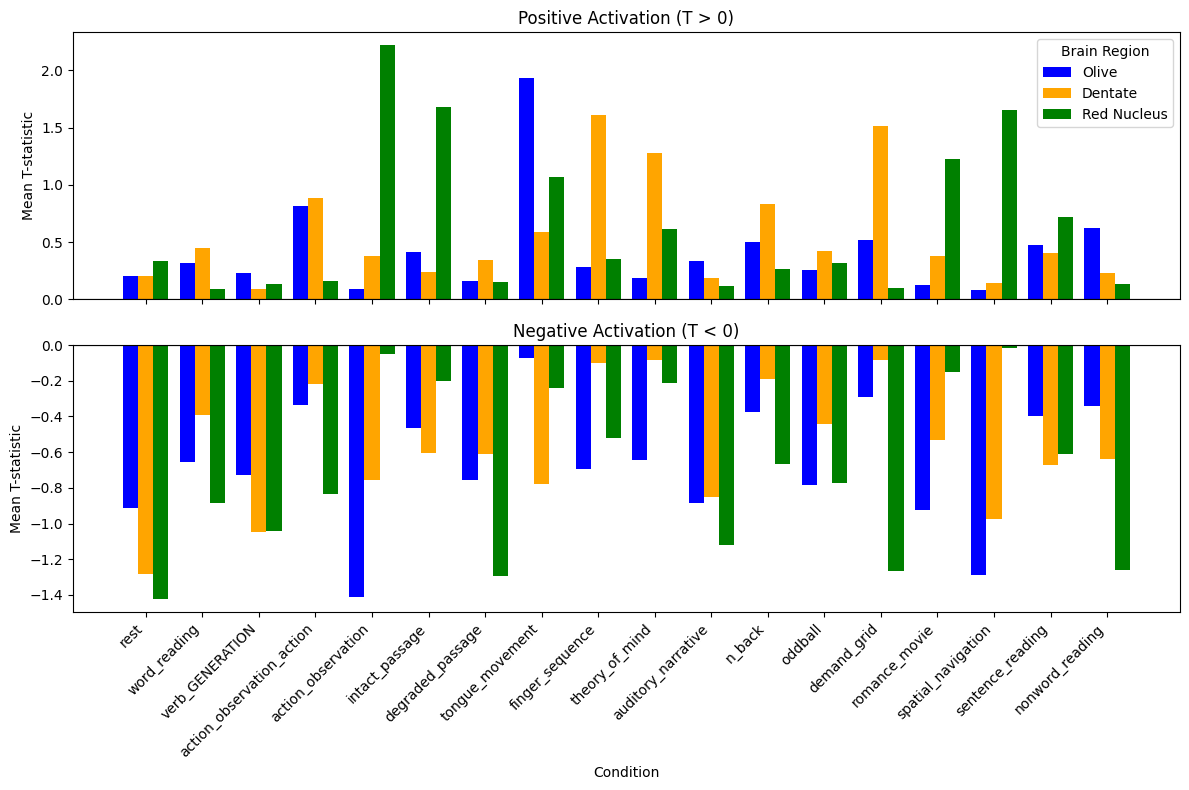

In [9]:
import nibabel as nb
import numpy as np
import matplotlib.pyplot as plt

wk_dir = f'/Volumes/diedrichsen_data$/data/Cerebellum/Pontine7T/atlases'

region_files = {
    "Olive": f"{wk_dir}/olive/contrasts/language_olive_condavg_Tstat.dscalar.nii",
    "Dentate": f"{wk_dir}/dentate/contrasts/language_condavg_Tstat.dscalar.nii",
    "Red Nucleus": f"{wk_dir}/rednucleus/contrasts/language_rednucleus_condavg_Tstat.dscalar.nii"
}

region_pos = {}
region_neg = {}
condition_names = None

# --- Load data ---
for region, path in region_files.items():
    img = nb.load(path)
    data = img.get_fdata()
    
    if condition_names is None:
        axis = img.header.get_axis(0)
        condition_names = axis.name
    
    # Split positive / negative
    pos = np.mean(np.where(data > 0, data, 0), axis=1)
    neg = np.mean(np.where(data < 0, data, 0), axis=1)
    
    region_pos[region] = pos
    region_neg[region] = neg

# --- Plot setup ---
x = np.arange(len(condition_names))
n_regions = len(region_files)
width = 0.8 / n_regions

colors = ["blue", "orange", "green"]

fig, axes = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# --- TOP: Positive activation ---
for i, (region, values) in enumerate(region_pos.items()):
    offset = (i - (n_regions - 1)/2) * width
    axes[0].bar(x + offset, values, width, label=region, color=colors[i])

axes[0].set_title("Positive Activation (T > 0)")
axes[0].set_ylabel("Mean T-statistic")
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].legend(title="Brain Region")

# --- BOTTOM: Negative activation ---
for i, (region, values) in enumerate(region_neg.items()):
    offset = (i - (n_regions - 1)/2) * width
    axes[1].bar(x + offset, values, width, label=region, color=colors[i])

axes[1].set_title("Negative Activation (T < 0)")
axes[1].set_ylabel("Mean T-statistic")
axes[1].axhline(0, color='black', linewidth=0.8)

# Shared x-axis
axes[1].set_xticks(x)
axes[1].set_xticklabels(condition_names, rotation=45, ha='right')
axes[1].set_xlabel("Condition")

plt.tight_layout()
plt.show()